In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('upi_transactions.csv')
df.head()

,Amount,BankNameReceived,BankNameSent,City,Currency,CustomerAccountNumber,CustomerAge,DeviceType,Gender,MerchantAccountNumber,MerchantName,PaymentMethod,PaymentMode,Purpose,RemainingBalance,Status,TransactionDate,TransactionID,TransactionTime,TransactionType
0,348.99,IDFC FIRST Bank,ICICI Bank,Ahmedabad,INR,CUST93774863057,30,POS Device,Male,MERC9703905715,MakeMyTrip,Mobile Number,P2M,Food,109751.36,Success,2025-02-22,UPI20250222000001,18:57:34,Debit
1,287.89,Kotak Mahindra Bank,Canara Bank,Indore,INR,CUST84987658854,23,Web,Female,MERC9256195745,Swiggy,Mobile Number,P2M,Food,172346.02,Success,2025-03-21,UPI20250321000002,11:48:21,Debit
2,827.77,HDFC Bank,Kotak Mahindra Bank,Ahmedabad,INR,CUST47238118820,58,iOS,Female,MERC9896606039,Local Kirana,QR Scan,P2M,Grocery,177452.31,Success,2025-04-30,UPI20250430000003,20:24:17,Debit
3,3695.29,Yes Bank,Axis Bank,Patna,INR,CUST56033091279,49,POS Device,Female,CUST96812569967,Individual Transfer,Bank Account,P2P,Rent,285232.70,Pending,2025-06-16,UPI20250616000004,20:49:03,Debit
4,614.42,IDFC FIRST Bank,Kotak Mahindra Bank,Patna,INR,CUST27650808629,68,POS Device,Female,CUST34169696708,Individual Transfer,Bank Account,P2P,Family Support,23896.65,Success,2025-10-27,UPI20251027000005,14:37:25,Debit


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Amount                 20000 non-null  float64
 1   BankNameReceived       20000 non-null  object 
 2   BankNameSent           20000 non-null  object 
 3   City                   20000 non-null  object 
 4   Currency               20000 non-null  object 
 5   CustomerAccountNumber  20000 non-null  object 
 6   CustomerAge            20000 non-null  int64  
 7   DeviceType             20000 non-null  object 
 8   Gender                 20000 non-null  object 
 9   MerchantAccountNumber  20000 non-null  object 
 10  MerchantName           20000 non-null  object 
 11  PaymentMethod          20000 non-null  object 
 12  PaymentMode            20000 non-null  object 
 13  Purpose                20000 non-null  object 
 14  RemainingBalance       20000 non-null  float64
 15  St

In [5]:
df.value_counts

<bound method DataFrame.value_counts of         Amount     BankNameReceived         BankNameSent        City Currency  \
0       348.99      IDFC FIRST Bank           ICICI Bank   Ahmedabad      INR   
1       287.89  Kotak Mahindra Bank          Canara Bank      Indore      INR   
2       827.77            HDFC Bank  Kotak Mahindra Bank   Ahmedabad      INR   
3      3695.29             Yes Bank            Axis Bank       Patna      INR   
4       614.42      IDFC FIRST Bank  Kotak Mahindra Bank       Patna      INR   
...        ...                  ...                  ...         ...      ...   
19995   882.98      IDFC FIRST Bank       Bank of Baroda        Pune      INR   
19996  1701.50            HDFC Bank            HDFC Bank  Coimbatore      INR   
19997   306.04           ICICI Bank  State Bank of India  Coimbatore      INR   
19998   242.67             Yes Bank          Canara Bank       Kochi      INR   
19999  3069.33           ICICI Bank  Union Bank of India     Chennai 

In [6]:
df['DeviceType'].value_counts()

DeviceType
Web           5058
POS Device    5009
iOS           4971
Android       4962
Name: count, dtype: int64

In [7]:
df['PaymentMethod'].value_counts()

PaymentMethod
Mobile Number    5078
UPI ID           5012
QR Scan          4984
Bank Account     4926
Name: count, dtype: int64

In [8]:
df['PaymentMode'].value_counts()

PaymentMode
P2M    12240
P2P     7760
Name: count, dtype: int64

In [9]:
df['Status'].value_counts()

Status
Success    18463
Failed      1128
Pending      409
Name: count, dtype: int64

In [10]:
df['TransactionType'].value_counts()

TransactionType
Debit     17210
Credit     2790
Name: count, dtype: int64

In [11]:
df['Status'] = df['Status'].str.strip().str.lower()

In [12]:
df['Status'].value_counts()

Status
success    18463
failed      1128
pending      409
Name: count, dtype: int64

# Feature Engg

**Create New Columns**

In [13]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 45:
        return "Adult"
    else:
        return "Senior"
df["AgeGroup"] = df["CustomerAge"].apply(age_group)

In [14]:
df["AgeGroup"].value_counts()

AgeGroup
Senior    9807
Adult     7523
Young     2670
Name: count, dtype: int64

**Transaction Success Flag**

In [15]:
df['IsSuccess'] = df['Status'].apply(lambda x: 1 if x == 'success' else 0)
df['IsSuccess'].value_counts()

IsSuccess
1    18463
0     1537
Name: count, dtype: int64

In [16]:
df["HighValue"] = df['Amount'].apply(lambda x: 1 if x > 1000 else 0)
df["HighValue"].value_counts()

HighValue
0    11985
1     8015
Name: count, dtype: int64

# Data Transformation (Aggregation Layer)

**📊 KPI Calculations**

In [17]:
total_transactions = len(df)
success_rate = df['IsSuccess'].mean() * 100
avg_amount = df['Amount'].mean()

print("Total Transaction : ", total_transactions)
print("Success Rate : ", success_rate)
print("Avg Amount : ", avg_amount)

Total Transaction :  20000
Success Rate :  92.315
Avg Amount :  2004.4505880000004


**📊 Grouped Insights**

In [18]:
device_analysis = df.groupby('DeviceType')['Amount'].sum()
age_analysis = df.groupby("AgeGroup")["Amount"].mean()
payment_mode_analysis = df.groupby("PaymentMode")["Amount"].sum()

print("Device Analysis", device_analysis)
print("Age Analysis", age_analysis)
print("Payment Mode Analysis", payment_mode_analysis)

Device Analysis DeviceType
Android        9785837.85
POS Device     9932203.25
Web           10373361.07
iOS            9997609.59
Name: Amount, dtype: float64
Age Analysis AgeGroup
Adult     1975.054083
Senior    2042.552690
Young     1947.327963
Name: Amount, dtype: float64
Payment Mode Analysis PaymentMode
P2M    13725733.94
P2P    26363277.82
Name: Amount, dtype: float64


In [19]:
df['RiskFlag'] = (
    (df['Amount'] > 2000) &
    (df['PaymentMode'] == 'P2P') &
    (df['DeviceType'] == "Web")
).astype(int)


df['RiskFlag'].value_counts()

RiskFlag
0    19271
1      729
Name: count, dtype: int64

In [20]:
numeric_cols = ["Amount", "CustomerAge", "RemainingBalance"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [21]:
features = df[numeric_cols]
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Amount            20000 non-null  float64
 1   CustomerAge       20000 non-null  int64  
 2   RemainingBalance  20000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 468.9 KB


# Build Model (Anomaly)

In [22]:
from sklearn.ensemble import IsolationForest

In [23]:
model = IsolationForest(contamination=0.02, random_state=42)

In [24]:
#Predict Anomalies

df['Anomaly'] = model.fit_predict(features)

In [25]:
df['FraudFlag'] = df['Anomaly'].map({
    1: "Normally",
    -1: "Suspicious"    
})

In [26]:
df['FraudFlag'].value_counts()

FraudFlag
Normally      19600
Suspicious      400
Name: count, dtype: int64

In [27]:
# Save output
df.to_csv("upi_fraud_output.csv", index=False)

print("Fraud detection completed successfully")

Fraud detection completed successfully


In [28]:
print(df[["Amount", "CustomerAge", "RemainingBalance"]].head(10))
print(df[["Amount", "CustomerAge", "RemainingBalance"]].dtypes)

    Amount  CustomerAge  RemainingBalance
0   348.99           30         109751.36
1   287.89           23         172346.02
2   827.77           58         177452.31
3  3695.29           49         285232.70
4   614.42           68          23896.65
5   268.41           50          80189.13
6   134.62           33         492540.75
7   338.44           46         270447.19
8   198.13           48         334621.78
9   449.99           46         430524.61
Amount              float64
CustomerAge           int64
RemainingBalance    float64
dtype: object


In [29]:
frauds = df[df['FraudFlag'] == "Suspicious"]
frauds.head()

,Amount,BankNameReceived,BankNameSent,City,Currency,CustomerAccountNumber,CustomerAge,DeviceType,Gender,MerchantAccountNumber,...,TransactionDate,TransactionID,TransactionTime,TransactionType,AgeGroup,IsSuccess,HighValue,RiskFlag,Anomaly,FraudFlag
160,15843.93,Canara Bank,Yes Bank,Kolkata,INR,CUST51169712660,21,Android,Male,CUST74930377009,...,2025-12-02,UPI20251202000161,08:22:14,Debit,Young,1,1,0,-1,Suspicious
304,14821.51,IndusInd Bank,IDFC FIRST Bank,Jaipur,INR,CUST78665889299,27,POS Device,Male,CUST46556246979,...,2025-10-31,UPI20251031000305,12:50:51,Debit,Adult,1,1,0,-1,Suspicious
317,17575.69,Yes Bank,IDFC FIRST Bank,Mumbai,INR,CUST43788305570,42,Android,Female,CUST73813108571,...,2025-05-03,UPI20250503000318,11:24:19,Credit,Adult,1,1,0,-1,Suspicious
320,69208.20,HDFC Bank,Axis Bank,Lucknow,INR,CUST15019768628,45,Web,Male,CUST93326810444,...,2025-08-01,UPI20250801000321,13:25:56,Debit,Senior,1,1,1,-1,Suspicious
337,29979.25,IDFC FIRST Bank,IndusInd Bank,Noida,INR,CUST35102070723,36,Android,Female,CUST38440596479,...,2025-12-03,UPI20251203000338,15:56:18,Debit,Adult,1,1,0,-1,Suspicious


In [30]:
frauds[["TransactionID","Amount","CustomerAge","RemainingBalance","FraudFlag"]]

,TransactionID,Amount,CustomerAge,RemainingBalance,FraudFlag
160,UPI20251202000161,15843.93,21,180015.14,Suspicious
304,UPI20251031000305,14821.51,27,460991.90,Suspicious
317,UPI20250503000318,17575.69,42,94120.88,Suspicious
320,UPI20250801000321,69208.20,45,85491.63,Suspicious
337,UPI20251203000338,29979.25,36,374144.07,Suspicious
...,...,...,...,...,...
19673,UPI20250420019674,29971.94,29,25933.90,Suspicious
19778,UPI20250130019779,28872.46,52,343917.87,Suspicious
19789,UPI20250728019790,16855.34,67,445172.94,Suspicious
19934,UPI20250629019935,11596.23,69,19778.29,Suspicious


In [31]:
frauds.to_csv(
    "fraud_transactions.csv",
    index=False
)

In [32]:
customer_df = df.groupby("CustomerAccountNumber").agg(
    TotalAmount = ("Amount", "sum"),
    AvgAmount = ("Amount", "mean"),
    TransactionCount=("TransactionID", "count"),
    AvgBalance = ("RemainingBalance", "mean")
)

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [34]:
customer_df.head()

,TotalAmount,AvgAmount,TransactionCount,AvgBalance
CustomerAccountNumber,,,,
CUST10000311359,749.31,749.31,1,367692.56
CUST10001035414,140.32,140.32,1,250125.92
CUST10003181749,1140.51,1140.51,1,444927.74
CUST10008125098,1041.07,1041.07,1,344391.83
CUST10009880661,10666.30,10666.30,1,88878.89


**Scaling Model**

In [35]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

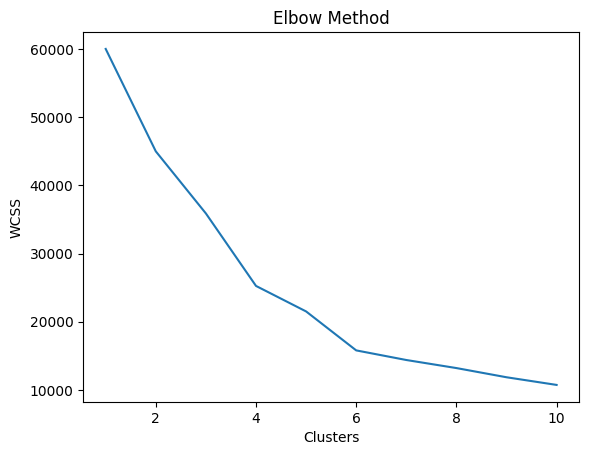

In [36]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [38]:
customer_df.head()

,TotalAmount,AvgAmount,TransactionCount,AvgBalance,Cluster
CustomerAccountNumber,,,,,
CUST10000311359,749.31,749.31,1,367692.56,0
CUST10001035414,140.32,140.32,1,250125.92,2
CUST10003181749,1140.51,1140.51,1,444927.74,0
CUST10008125098,1041.07,1041.07,1,344391.83,1
CUST10009880661,10666.30,10666.30,1,88878.89,0


In [39]:
customer_df["CustomerSegment"] = customer_df[
    "Cluster"
    ].map({
        0:"Premium Users",
        1:"Regular Users",
        2:"Low Value Users",
        3:"High Frequency Users"
    })

In [40]:
customer_df.groupby("CustomerSegment")[["TotalAmount","TransactionCount","AvgBalance"]
].mean()

,TotalAmount,TransactionCount,AvgBalance
CustomerSegment,,,
High Frequency Users,2023.437510,1.0,257255.027075
Low Value Users,2096.422627,1.0,248305.143975
Premium Users,1923.948643,1.0,250285.950583
Regular Users,2009.766968,1.0,248940.149071


In [41]:
customer_df = df.groupby(
    "CustomerAccountNumber"
).agg(
    TotalAmount=("Amount", "sum"),
    AvgAmount=("Amount", "mean"),
    TransactionCount=("TransactionID", "count"),
    AvgBalance=("RemainingBalance", "mean")
).reset_index()

In [42]:
customer_df.head()

,CustomerAccountNumber,TotalAmount,AvgAmount,TransactionCount,AvgBalance
0,CUST10000311359,749.31,749.31,1,367692.56
1,CUST10001035414,140.32,140.32,1,250125.92
2,CUST10003181749,1140.51,1140.51,1,444927.74
3,CUST10008125098,1041.07,1041.07,1,344391.83
4,CUST10009880661,10666.30,10666.30,1,88878.89


In [43]:
customer_df.to_csv("customer_segments.csv",index=False)

In [44]:
from datetime import datetime

In [45]:
# Load data
df = pd.read_csv("upi_transactions.csv")

In [46]:
# Cleaning
df.dropna(inplace=True)
df['Amount'] = df['Amount'].astype(float)


In [47]:
# Feature Engineering
df['IsSuccess'] = df['Status'].apply(lambda x: 1 if x.lower() == 'success' else 0)


In [51]:
#Save cleaned file
df.to_csv("cleaned_upi_data.csv", index=False)

In [49]:
print(f"Pipeline executed at {datetime.now()}")

Pipeline executed at 2026-06-10 16:18:32.985351
